In [1]:
import pandas as pd
df=pd.read_csv("AirPassengers.csv")
df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [3]:
df.shape

(144, 2)

In [4]:
df.describe()

,#Passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


In [5]:
df.isnull().sum()

Month          0
#Passengers    0
dtype: int64

In [6]:
data=df["#Passengers"].values  #target column

from sklearn.preprocessing import MinMaxScaler
sc=MinMaxScaler()
data=sc.fit_transform(data.reshape(-1,1))  #Converts 1D → 2D (required by scaler)
#LSTM uses gradient descent → sensitive to scale
#Large values → unstable learning
#So we scale data to [0,1]

In [7]:
import numpy as np

#LSTM doesn’t take single values → it takes sequences
def create_dataset(data, time_step=5):
    X, y = [], []
    for i in range(len(data)-time_step-1):
        X.append(data[i:(i+time_step), 0])  #past value
        y.append(data[i+time_step, 0])  #next value
    return np.array(X), np.array(y)  #final shape -> X → (samples, time_step), y → (samples,)

time_step = 5
X, y = create_dataset(data, time_step)

In [8]:
train_size = int(len(X)*0.8)

#no random shuffling cuz order needs to be preserved
X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [9]:
#reshape cuz lstm wants (samples, time_steps, features)

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(50, return_sequences=False, input_shape=(time_step,1)),  #50 memory units (neurons) Learns temporal patterns, return seq is false cuz we want single output
    Dense(1)  #Final output = next value prediction
])

model.compile(optimizer='adam', loss='mse')
model.summary()

C:\Users\anjan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.fit(X_train, y_train, epochs=20, batch_size=16)
#Forward pass → prediction
#Error calculation (MSE)
#Backpropagation through time (BPTT)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0839
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0435 
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0190 
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0125 
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0143 
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0118 
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0104
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0103 
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0097
Epoch 10/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0090 
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0087 
Epoch 12/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0085 
Epoch 13/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0082 
Epoch 14/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0081 
Epoch 15/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0081 
Epoch 16/20
7/7 ━━━━━━━━━━━━━━━━━━

In [12]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# inverse transform to get back original format values for better plotting
train_pred = sc.inverse_transform(train_pred)
test_pred = sc.inverse_transform(test_pred)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


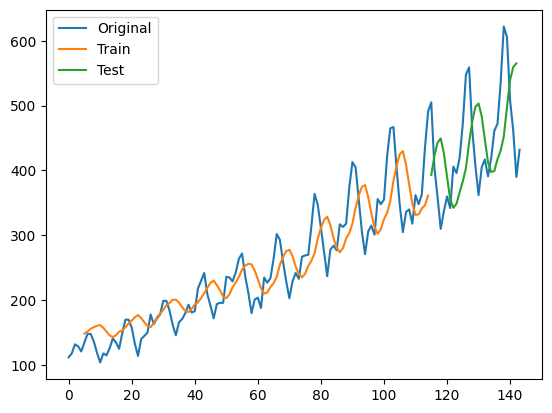

In [14]:
import matplotlib.pyplot as plt

plt.plot(sc.inverse_transform(data), label="Original")
plt.plot(range(time_step, len(train_pred)+time_step), train_pred, label="Train")
plt.plot(range(len(train_pred)+time_step, len(train_pred)+len(test_pred)+time_step), test_pred, label="Test")
plt.legend()
plt.show()
#x axis is time step
#y axis is no. of passengers